# Ground-truth morphometric diagnostic: mitotic vs. look-alike vs. ordinary nucleus, per domain

**Purpose.** Everything in `find_and_suppress`, `evaluate.py`'s score-based diagnostics,
and the fusion/augmentation-variant sweeps depends on `cv2.matchTemplate` against a
51 px annotation box whose *own* correctness (is 51 px even the right size for a given
object, in a given domain?) has not been separately verified. This notebook asks the
separability question a different way, with **no template matching and no fixed 50x50
box anywhere in the measurement**:

1. Otsu-segment the actual nucleus under every category-1 (mitotic) and category-2
   (look-alike) click, using `seed_selection.tighten_box_otsu` -- the same accept/reject
   logic the pipeline already uses for seed selection, applied here to *every*
   annotation rather than one seed per image.
2. Do the same at a sample of `baselines.nucleus_blobs` locations (the existing "any dark
   nucleus" baseline detector) that don't sit on any annotation, to get a same-method
   reading of the "ordinary nucleus" population that is the bulk of the false-positive
   problem but isn't itself annotated in MIDOG++.
3. Compare simple shape/intensity features (area, solidity, eccentricity, elongation,
   extent, hematoxylin intensity, and the segmented object's own native size) across the
   three populations, per tumour domain.

This is deliberately independent of `FSConfig`, `template_match.py`, and any score
threshold, so it can't be confounded by the open bbox-size question, and it produces an
empirical answer to that question as a side effect (§4 below).

**Cost.** All measurement is Otsu thresholding + `skimage.measure.regionprops` on small
crops -- no correlation, no augmentation bank, no iteration. The only per-image cost that
scales with image size is `baselines.nucleus_blobs`, which the pipeline already runs
elsewhere as a baseline. Expect roughly 30-70s per image, ~10-15 minutes for all 14
downloaded images -- a one-time cost, not a per-configuration sweep.

In [1]:
import sys, time, pathlib
sys.path.insert(0, '..') if 'midog_utils' not in __import__('os').listdir('.') else None

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.filters import threshold_multiotsu
from sklearn.neighbors import KDTree

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import baselines as bl, seed_selection as ss, evaluate as ev

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)          # every bbox is 50x50 and TLBR, or this raises
print(f'{len(images)} annotated images, {len(annotations)} annotations')

503 annotated images, 26286 annotations


## 1. Which images

**All 14 downloaded ROIs**, not just the single densest-per-domain ROI
`experiment.select_domain_images` picks for the TM experiments. That rule exists to keep
`recall@K` well-defined at a fixed budget -- irrelevant here, since nothing in this
notebook is scored against a budget. Using both downloaded images per domain roughly
doubles the annotation count feeding each domain's histograms, which matters most for the
domains with very few mitotic annotations in any single ROI (human breast cancer,
neuroendocrine, melanoma).

In [2]:
images_dir = 'images'
on_disk = sorted(p.name for p in pathlib.Path(images_dir).glob('*.tiff'))

counts = (annotations[annotations.category_id == ds.MITOTIC]
          .groupby('file_name').size().rename('n_mitotic'))
counts_look = (annotations[annotations.category_id == ds.LOOKALIKE]
               .groupby('file_name').size().rename('n_lookalike'))
overview = (images[images.file_name.isin(on_disk)]
            .merge(counts, left_on='file_name', right_index=True, how='left')
            .merge(counts_look, left_on='file_name', right_index=True, how='left')
            .fillna(0))
overview[['n_mitotic', 'n_lookalike']] = overview[['n_mitotic', 'n_lookalike']].astype(int)
overview = overview.sort_values(['tumor_type', 'file_name']).reset_index(drop=True)
print(f"{overview.tumor_type.nunique()} domains, {len(overview)} images")
overview[['file_name', 'tumor_type', 'n_mitotic', 'n_lookalike']]

7 domains, 14 images


,file_name,tumor_type,n_mitotic,n_lookalike
0,300.tiff,canine cutaneous mast cell tumor,181,85
1,301.tiff,canine cutaneous mast cell tumor,218,109
2,201.tiff,canine lung cancer,18,49
3,202.tiff,canine lung cancer,16,28
4,245.tiff,canine lymphosarcoma,90,70
5,246.tiff,canine lymphosarcoma,116,123
6,405.tiff,canine soft tissue sarcoma,14,19
7,406.tiff,canine soft tissue sarcoma,6,43
8,001.tiff,human breast cancer,0,4
9,002.tiff,human breast cancer,9,7


## 2. Method: same segmentation, three populations

`segment_click` below does exactly what `seed_selection.tighten_box_otsu` does --
same threshold, same `min_area`/`max_area_frac`/`min_solidity` gates, same
`center_tolerance=0` (exact-pixel) convention -- and additionally returns the full
`regionprops` object `tighten_box_otsu` computes internally but only returns the bbox
from. It's written as a thin wrapper around `tighten_box_otsu` itself (not a
reimplementation of its thresholding logic) specifically so the accept/reject decision
here is always identical to the pipeline's own: nothing about which clicks pass or fail
segmentation is redefined by this notebook.

Two departures from the existing pipeline's own convention, both deliberate:

- **Channel**: `hematoxylin`, not `gray_inverted`. `channels.py` documents hematoxylin as
  the channel that "should travel better across the four scanners in this dataset" --
  exactly the property a cross-domain comparison needs. `experiment.py` uses
  `gray_inverted` for seed selection for a different reason (consistency with whatever
  `FSConfig.channel` is being tested), which doesn't apply here since no matching is
  happening.
- **Otsu window**: fixed at `template_match.BASE_SIZE` (51px, the annotation box) for
  *all three* populations, including the `nucleus_blobs` candidates whose own native
  component can be larger. This isn't a bug to fix -- it deliberately measures what a
  51px-windowed segmentation sees for each population, since that is the window the
  current pipeline's template actually operates in. A component that doesn't fit is
  truncated at the window edge, which mainly affects `extent`/`solidity` for the larger
  ordinary-nucleus components; kept in mind when reading §5.

In [3]:
OTSU_WINDOW = tm.BASE_SIZE  # 51px -- see rationale above


def segment_click(structural_channel, cx, cy, otsu_window=OTSU_WINDOW,
                   method='binary', center_tolerance=0):
    '''Otsu-segment the nucleus under one click. Returns a skimage RegionProperties or None.

    Delegates the accept/reject decision entirely to `seed_selection.tighten_box_otsu`;
    only re-derives the same binary mask afterwards to recover the region object that
    function computes but doesn't return.
    '''
    patch = tm.read_padded_patch(structural_channel, cx, cy, otsu_window)
    if patch is None:
        return None
    bbox = ss.tighten_box_otsu(patch, method=method, center_tolerance=center_tolerance)
    if bbox is None:
        return None
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if method == 'binary':
        _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        thresholds = threshold_multiotsu(u8, classes=3)
        binary = np.where(u8 > thresholds[-1], np.uint8(255), np.uint8(0))
    labels = label(binary, connectivity=2)
    cyc, cxc = patch.shape[0] // 2, patch.shape[1] // 2
    lbl = labels[cyc, cxc]           # center_tolerance=0 only: the click's own pixel
    if lbl == 0:
        return None
    return next(r for r in regionprops(labels, intensity_image=patch) if r.label == lbl)


def region_row(region):
    y0, x0, y1, x1 = region.bbox
    minor = region.axis_minor_length
    return {
        'area': region.area,
        'solidity': region.solidity,
        'eccentricity': region.eccentricity,
        'perimeter': region.perimeter,
        'extent': region.extent,
        'major_axis_length': region.axis_major_length,
        'minor_axis_length': minor,
        'elongation': region.axis_major_length / minor if minor > 0 else np.nan,
        'mean_intensity': region.mean_intensity,   # hematoxylin OD within the mask
        'tightened_size': max(y1 - y0, x1 - x0),   # what tightened_base_size would return
    }

## 3. Extract features for all three populations, all 14 images

For each image: decode once, build the hematoxylin channel once, run
`baselines.nucleus_blobs` once (the expensive step -- full-ROI tiled Otsu, already used
elsewhere in the pipeline as the "any dark blob" baseline), drop any blob within the
MIDOG match radius of an annotation (so "ordinary nucleus" means "unannotated", not
"annotated object the blob detector also happened to find" -- same filter
`experiment._probe_variants` uses), then subsample to `N_NUCLEUS_SAMPLE` so segmentation
cost doesn't scale with the full 15-20k candidate list a dense ROI can produce.

This cell is the one that takes several minutes; it prints per-image timing as it goes.

In [4]:
rng = np.random.default_rng(0)
N_NUCLEUS_SAMPLE = 300

t_start = time.time()
rows, coverage = [], []

for file_name in on_disk:
    path = f'{images_dir}/{file_name}'
    t0 = time.time()
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    radius = ev.radius_px(mpp)
    tumor_type = images.loc[images.file_name == file_name, 'tumor_type'].iloc[0]

    h_chan = ch.to_hematoxylin(rgb)
    gt = ds.image_annotations(annotations, file_name)
    mit = gt[gt.category_id == ds.MITOTIC]
    look = gt[gt.category_id == ds.LOOKALIKE]

    mask = bl.tissue_mask(rgb)
    blobs = bl.nucleus_blobs(rgb, mask)
    if len(blobs):
        near = KDTree(ds.points(gt)).query_radius(blobs[['cx', 'cy']].to_numpy(), r=radius)
        blobs = blobs[[len(c) == 0 for c in near]].reset_index(drop=True)
    if len(blobs) > N_NUCLEUS_SAMPLE:
        blobs = blobs.sample(N_NUCLEUS_SAMPLE, random_state=int(rng.integers(1 << 30))).reset_index(drop=True)

    for klass, df in [('mitotic', mit), ('lookalike', look), ('ordinary_nucleus', blobs)]:
        n_ok = 0
        for _, r in df.iterrows():
            region = segment_click(h_chan, r['cx'], r['cy'])
            if region is None:
                continue
            n_ok += 1
            row = {'file_name': file_name, 'tumor_type': tumor_type, 'klass': klass,
                   'cx': r['cx'], 'cy': r['cy']}
            row.update(region_row(region))
            rows.append(row)
        coverage.append({'file_name': file_name, 'tumor_type': tumor_type, 'klass': klass,
                          'n_total': len(df), 'n_segmented': n_ok})

    print(f'{file_name:>10} ({tumor_type:<33}) {time.time()-t0:5.1f}s  '
          f'mit={len(mit):3d} look={len(look):3d} nucleus_sampled={len(blobs):3d}', flush=True)

print(f'\nTotal: {time.time()-t_start:.0f}s')
feat = pd.DataFrame(rows)
cov = pd.DataFrame(coverage)

pathlib.Path('results').mkdir(exist_ok=True)
feat.to_csv('results/morph_diag_features.csv', index=False)
cov.to_csv('results/morph_diag_coverage.csv', index=False)
print(f'{len(feat)} segmented objects saved to results/morph_diag_features.csv')

  001.tiff (human breast cancer              )  22.4s  mit=  0 look=  4 nucleus_sampled=300


  002.tiff (human breast cancer              )  22.7s  mit=  9 look=  7 nucleus_sampled=300


  201.tiff (canine lung cancer               )  42.6s  mit= 18 look= 49 nucleus_sampled=300


  202.tiff (canine lung cancer               )  68.6s  mit= 16 look= 28 nucleus_sampled=300


  245.tiff (canine lymphosarcoma             )  23.2s  mit= 90 look= 70 nucleus_sampled=300


...

  405.tiff (canine soft tissue sarcoma       )  12.9s  mit= 14 look= 19 nucleus_sampled=300


  406.tiff (canine soft tissue sarcoma       )  15.3s  mit=  6 look= 43 nucleus_sampled=300


  505.tiff (human melanoma                   )  15.5s  mit=  2 look= 10 nucleus_sampled=300


  506.tiff (human melanoma                   )  14.7s  mit= 12 look= 12 nucleus_sampled=300



Total: 366s
4348 segmented objects saved to results/morph_diag_features.csv


## 4. Coverage -- how often does Otsu even find something

If a class fails to segment often in a given domain, every downstream feature number for
that class/domain is drawn from a biased, incomplete subset (whatever *did* threshold
cleanly) -- worth knowing before trusting the separability numbers in §6.

In [5]:
cov_pivot = cov.pivot_table(index=['tumor_type', 'file_name'], columns='klass',
                            values=['n_total', 'n_segmented'], aggfunc='sum')
for klass in ['mitotic', 'lookalike', 'ordinary_nucleus']:
    cov_pivot[('pct_segmented', klass)] = (
        100 * cov_pivot[('n_segmented', klass)] / cov_pivot[('n_total', klass)].replace(0, np.nan)
    ).round(1)
cov_pivot[[('pct_segmented', k) for k in ['mitotic', 'lookalike', 'ordinary_nucleus']]]

pct_segmented                           
klass                                            mitotic lookalike ordinary_nucleus
tumor_type                       file_name                                         
canine cutaneous mast cell tumor 300.tiff           79.0      80.0             73.7
                                 301.tiff           74.3      78.0             87.0
canine lung cancer               201.tiff           83.3      98.0             73.3
                                 202.tiff           93.8      89.3             68.7
canine lymphosarcoma             245.tiff           83.3      78.6             85.3
                                 246.tiff           81.0      63.4             56.3
canine soft tissue sarcoma       405.tiff           71.4      94.7             93.0
                                 406.tiff           50.0      90.7             82.3
human breast cancer              001.tiff            NaN     100.0             83.0
                                 002.tiff           88.9      85.7             79.3
human melanoma                   505.tiff          100.0      50.0             79.7
                                 506.tiff          100.0      75.0             84.0
human neuroendocrine tumor       350.tiff          100.0      93.8             85.0
                                 351.tiff           75.0      70.2             71.7

## 5. Does bbox size even matter -- empirical answer

`tightened_size` is exactly what `seed_selection.tightened_base_size` would return for
each click (the odd side length of its own Otsu component) -- computed here for *every*
mitotic and look-alike annotation across all 14 images, not the one seed per image the
main pipeline samples. Compare its distribution against the fixed 51px box
(`template_match.BASE_SIZE`) the un-tightened pipeline default uses.

In [6]:
size_summary = (feat[feat.klass.isin(['mitotic', 'lookalike'])]
                 .groupby(['tumor_type', 'klass'])['tightened_size']
                 .agg(n='count', p10=lambda s: s.quantile(0.10), median='median',
                      p90=lambda s: s.quantile(0.90))
                 .round(1))
print(f'Current fixed template size (template_match.BASE_SIZE): {tm.BASE_SIZE}px\n')
size_summary

Current fixed template size (template_match.BASE_SIZE): 51px



n   p10  median   p90
tumor_type                       klass                             
canine cutaneous mast cell tumor lookalike  153  18.0    24.0  32.0
                                 mitotic    305  20.0    24.0  28.0
canine lung cancer               lookalike   73  21.0    29.0  42.0
                                 mitotic     30  20.9    29.0  35.2
canine lymphosarcoma             lookalike  133  20.0    26.0  39.0
                                 mitotic    169  22.0    27.0  35.0
canine soft tissue sarcoma       lookalike   57  22.0    29.0  39.8
                                 mitotic     13  24.6    41.0  49.8
human breast cancer              lookalike   10  26.4    33.0  42.1
                                 mitotic      8  28.1    33.0  42.4
human melanoma                   lookalike   14  27.3    32.5  39.8
                                 mitotic     14  24.9    28.5  36.0
human neuroendocrine tumor       lookalike   55  23.0    29.0  39.2
                                 mitotic      7  27.2    30.0  35.2

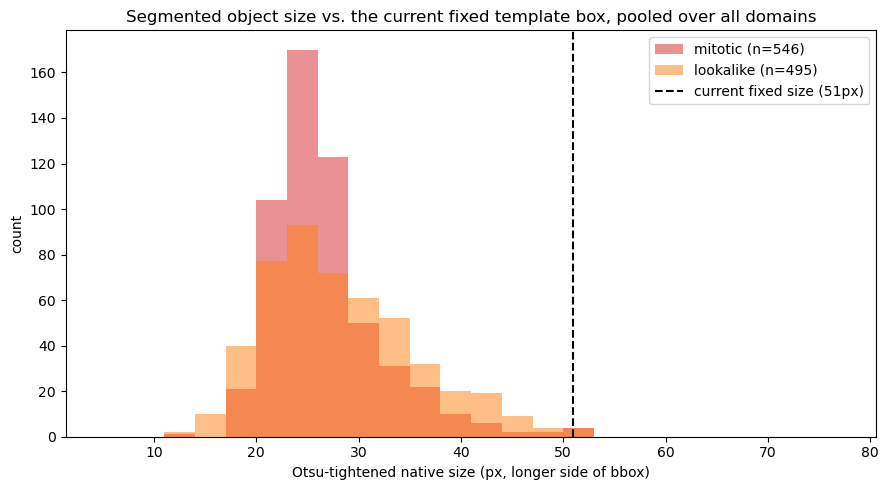

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for klass, color in [('mitotic', 'tab:red'), ('lookalike', 'tab:orange')]:
    vals = feat.loc[feat.klass == klass, 'tightened_size']
    ax.hist(vals, bins=np.arange(5, 80, 3), alpha=0.5, label=f'{klass} (n={len(vals)})', color=color)
ax.axvline(tm.BASE_SIZE, color='k', linestyle='--', label=f'current fixed size ({tm.BASE_SIZE}px)')
ax.set_xlabel('Otsu-tightened native size (px, longer side of bbox)')
ax.set_ylabel('count')
ax.set_title('Segmented object size vs. the current fixed template box, pooled over all domains')
ax.legend()
fig.tight_layout()
plt.show()

## 6. Feature separability per domain

Bhattacharyya distance between two classes' histograms for one feature: 0 = identical
distributions (complete overlap), larger = more separated. This is the same idea as the
score-overlap diagnostic from before, applied to features that don't depend on template
matching or bbox size at all.

Read the `n_mitotic` column before trusting a domain's row -- several domains have well
under 20 mitotic annotations even pooling both images, and a Bhattacharyya distance from
a small sample is noisy.

In [8]:
def bhattacharyya_distance(a, b, bins=25):
    a = np.asarray(a, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(b, dtype=float); b = b[~np.isnan(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    if hi <= lo:
        return 0.0
    edges = np.linspace(lo, hi, bins + 1)
    pa, _ = np.histogram(a, bins=edges)
    pb, _ = np.histogram(b, bins=edges)
    pa = pa / pa.sum() if pa.sum() else pa.astype(float)
    pb = pb / pb.sum() if pb.sum() else pb.astype(float)
    bc = float(np.sum(np.sqrt(pa * pb)))
    return -np.log(max(bc, 1e-12))


FEATURES = ['area', 'solidity', 'eccentricity', 'elongation', 'extent',
            'mean_intensity', 'tightened_size']

bd_rows = []
for domain in sorted(feat.tumor_type.unique()):
    sub = feat[feat.tumor_type == domain]
    mit = sub[sub.klass == 'mitotic']
    look = sub[sub.klass == 'lookalike']
    nuc = sub[sub.klass == 'ordinary_nucleus']
    row = {'tumor_type': domain, 'n_mitotic': len(mit), 'n_lookalike': len(look),
           'n_ordinary_nucleus': len(nuc)}
    for feature in FEATURES:
        row[f'{feature}__vs_nucleus'] = round(bhattacharyya_distance(mit[feature], nuc[feature]), 3)
        row[f'{feature}__vs_lookalike'] = round(bhattacharyya_distance(mit[feature], look[feature]), 3)
    bd_rows.append(row)

bd = pd.DataFrame(bd_rows).set_index('tumor_type')
bd.to_csv('results/morph_diag_bhattacharyya.csv')
bd

,n_mitotic,n_lookalike,n_ordinary_nucleus,area__vs_nucleus,area__vs_lookalike,solidity__vs_nucleus,solidity__vs_lookalike,eccentricity__vs_nucleus,eccentricity__vs_lookalike,elongation__vs_nucleus,elongation__vs_lookalike,extent__vs_nucleus,extent__vs_lookalike,mean_intensity__vs_nucleus,mean_intensity__vs_lookalike,tightened_size__vs_nucleus,tightened_size__vs_lookalike
tumor_type,,,,,,,,,,,,,,,,,
canine cutaneous mast cell tumor,305,153,482,0.232,0.052,0.191,0.057,0.030,0.058,0.014,0.048,0.097,0.036,1.376,0.192,0.270,0.108
canine lung cancer,30,73,426,0.251,0.122,0.696,0.169,0.117,0.154,0.056,0.138,0.393,0.210,2.139,0.332,0.491,0.209
canine lymphosarcoma,169,133,425,0.179,0.083,0.149,0.158,0.075,0.086,0.060,0.086,0.109,0.069,1.047,0.161,0.185,0.137
canine soft tissue sarcoma,13,57,526,0.483,0.636,0.300,0.481,0.409,0.689,0.169,0.591,0.407,0.435,1.178,0.763,0.415,0.971
human breast cancer,8,10,487,0.539,0.746,0.691,0.534,0.709,1.310,0.159,2.191,0.499,0.963,2.046,1.498,0.748,1.092
human melanoma,14,14,491,0.207,0.603,0.477,1.054,0.403,1.001,0.111,0.718,0.284,1.758,0.925,0.693,0.556,0.509
human neuroendocrine tumor,7,55,470,0.711,0.658,1.051,0.722,0.685,0.813,0.110,0.791,0.669,0.863,3.703,1.258,0.595,0.680


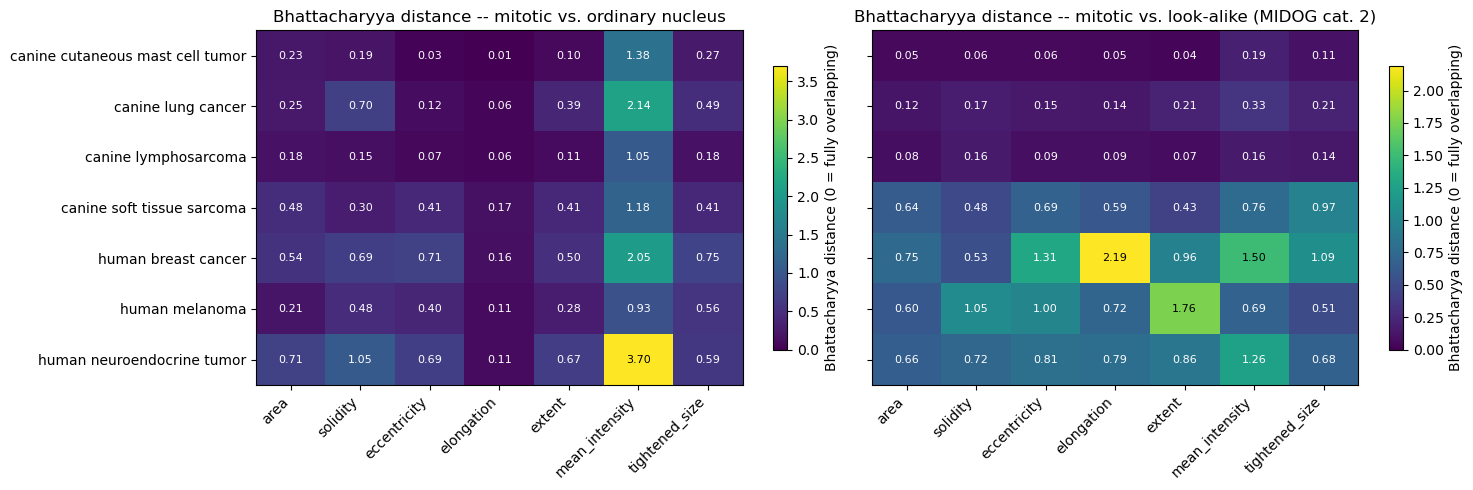

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
domains = bd.index.tolist()
for ax, suffix, title in zip(axes, ['__vs_nucleus', '__vs_lookalike'],
                              ['mitotic vs. ordinary nucleus', 'mitotic vs. look-alike (MIDOG cat. 2)']):
    mat = bd[[f'{f}{suffix}' for f in FEATURES]].to_numpy(dtype=float)
    im = ax.imshow(mat, aspect='auto', cmap='viridis', vmin=0)
    ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha='right')
    ax.set_yticks(range(len(domains))); ax.set_yticklabels(domains)
    ax.set_title(f'Bhattacharyya distance -- {title}')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                        color='white' if mat[i, j] < np.nanmax(mat) * 0.6 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8, label='Bhattacharyya distance (0 = fully overlapping)')
fig.tight_layout()
plt.show()

## 7. Per-feature histograms, by domain

The three most informative features from §6, plotted per domain, so a high or low
Bhattacharyya number can be checked against the actual shape of the overlap rather than
trusted as a single number.

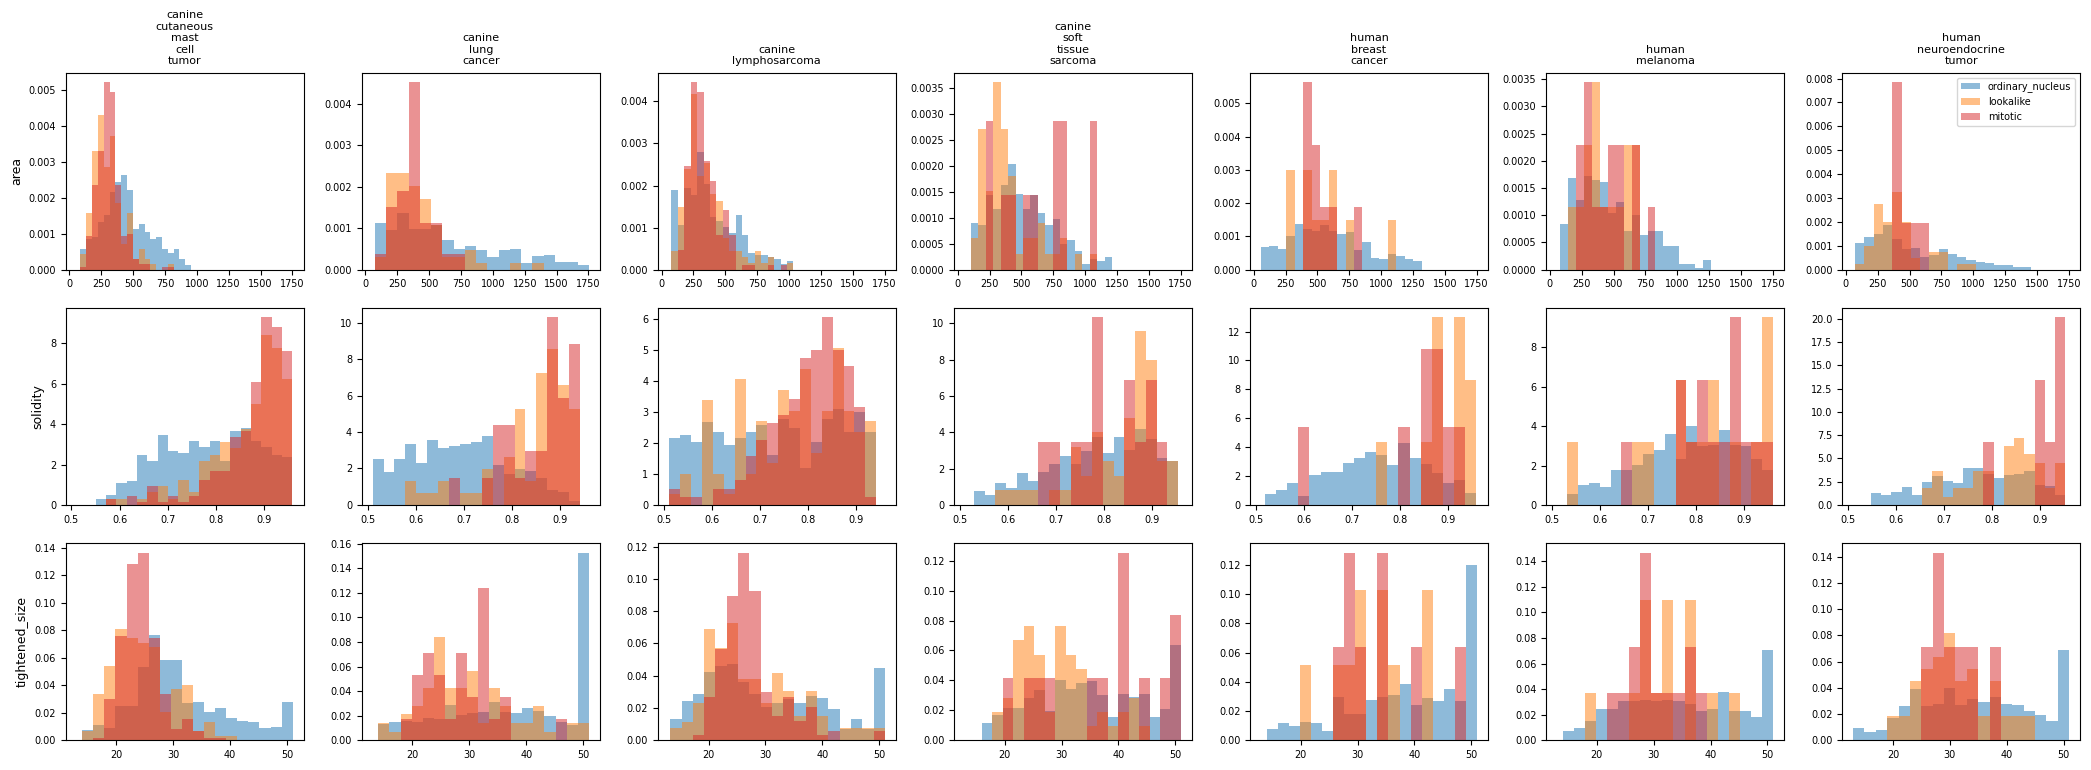

In [10]:
plot_features = ['area', 'solidity', 'tightened_size']
domains = sorted(feat.tumor_type.unique())
fig, axes = plt.subplots(len(plot_features), len(domains),
                          figsize=(3 * len(domains), 2.6 * len(plot_features)), sharex='row')
colors = {'mitotic': 'tab:red', 'lookalike': 'tab:orange', 'ordinary_nucleus': 'tab:blue'}

for i, feature in enumerate(plot_features):
    for j, domain in enumerate(domains):
        ax = axes[i, j]
        sub = feat[feat.tumor_type == domain]
        lo, hi = sub[feature].quantile(0.01), sub[feature].quantile(0.99)
        bins = np.linspace(lo, hi, 20) if hi > lo else 20
        for klass in ['ordinary_nucleus', 'lookalike', 'mitotic']:
            vals = sub.loc[sub.klass == klass, feature].dropna()
            if len(vals):
                ax.hist(vals, bins=bins, density=True, alpha=0.5, color=colors[klass], label=klass)
        if i == 0:
            ax.set_title(domain.replace(' ', '\n'), fontsize=8)
        if j == 0:
            ax.set_ylabel(feature, fontsize=9)
        ax.tick_params(labelsize=7)

axes[0, -1].legend(fontsize=7, loc='upper right')
fig.tight_layout()
plt.show()

## How to read this

- **§4 (coverage)** flags any class/domain where Otsu segmentation itself is unreliable --
  a low `pct_segmented` means the feature numbers for that cell are drawn from a biased
  subset, not the full population.
- **§5 (size)** is the direct, TM-independent answer to the bbox-size question: compare
  the `tightened_size` distribution against the current fixed 51px box per domain. If
  mitotic figures in a domain run consistently smaller or larger than 51px, that domain's
  template is systematically mismatched regardless of anything the score-based
  diagnostics could show.
- **§6/§7 (separability)** answer the "what approach next" question. A feature with a
  large Bhattacharyya distance against *both* ordinary nuclei and look-alikes, consistently
  across domains, is a strong stage-2-classifier candidate. A feature that only separates
  mitotic figures from ordinary nuclei but not from look-alikes confirms the mimicker
  problem specifically -- the pathologist-rejected candidates need a different feature (or
  a different channel/texture measure) than what separates mitosis from generic chromatin.
  If nothing separates well anywhere, that's evidence classical morphometric features
  aren't sufficient and the next step should look at texture (Haralick/GLCM) or a learned
  feature instead, before investing further in classical thresholds.